# Práctica: Construcción progresiva de una CNN para clasificación de imágenes

**Módulo:** Computer Vision  
**Tema:** Deep Learning aplicado a imagen  
**Objetivo:** aprender a construir una red neuronal convolucional paso a paso, evaluando cómo afecta cada decisión arquitectónica.

---

## Objetivos de aprendizaje

Al finalizar esta práctica, deberías ser capaz de:

- Cargar y preprocesar datasets de imágenes.
- Construir una red densa básica como baseline.
- Construir CNNs progresivamente más complejas.
- Entender el papel de `Conv2D`, `MaxPooling2D`, `Flatten`, `Dense`, `Dropout` y `BatchNormalization`.
- Evaluar modelos con accuracy, loss y matriz de confusión.
- Comparar el comportamiento de una CNN sobre un dataset sencillo y otro más complejo.
- Extraer conclusiones sobre sobreentrenamiento, generalización y mejoras posibles.

---

## Datasets usados

Trabajaremos con dos datasets:

1. **MNIST**: imágenes en escala de grises de dígitos manuscritos.
2. **CIFAR-10**: imágenes RGB de objetos y animales en 10 clases.

# 1. Importación de librerías

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import mnist, cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
)
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [2]:
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# Parte A — Dataset sencillo: MNIST

MNIST contiene imágenes de dígitos manuscritos del 0 al 9.

Cada imagen tiene tamaño **28 × 28 píxeles** y está en **escala de grises**.

# 2. Carga de MNIST

In [3]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
X_train: (60000, 28, 28)
y_train: (60000,)
X_test: (10000, 28, 28)
y_test: (10000,)


## Preguntas

1. ¿Qué tamaño tienen las imágenes?
2. ¿Cuántas imágenes hay para entrenamiento?
3. ¿Cuántas imágenes hay para test?
4. ¿Cuántas clases hay?
5. ¿Las imágenes son en color o en escala de grises?

# 3. Visualización inicial

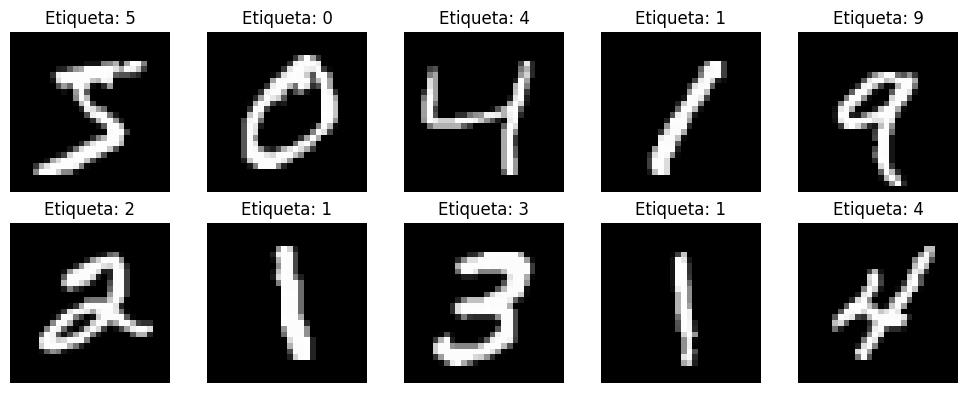

In [4]:
plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(f"Etiqueta: {y_train[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

# 4. Preprocesado de MNIST

Normalizamos las imágenes dividiendo entre 255 para que los valores queden en el rango `[0, 1]`.

Además, añadimos una dimensión de canal, ya que Keras espera tensores con forma:

`(n_imágenes, alto, ancho, canales)`

In [5]:
X_train_mnist = X_train.astype("float32") / 255.0
X_test_mnist = X_test.astype("float32") / 255.0

X_train_mnist = X_train_mnist.reshape(-1, 28, 28, 1)
X_test_mnist = X_test_mnist.reshape(-1, 28, 28, 1)

y_train_mnist_cat = to_categorical(y_train, 10)
y_test_mnist_cat = to_categorical(y_test, 10)

print("X_train_mnist:", X_train_mnist.shape)
print("X_test_mnist:", X_test_mnist.shape)
print("y_train_mnist_cat:", y_train_mnist_cat.shape)
print("y_test_mnist_cat:", y_test_mnist_cat.shape)

X_train_mnist: (60000, 28, 28, 1)
X_test_mnist: (10000, 28, 28, 1)
y_train_mnist_cat: (60000, 10)
y_test_mnist_cat: (10000, 10)


## Preguntas

1. ¿Por qué dividimos entre 255?
2. ¿Por qué añadimos una dimensión final con valor 1?
3. ¿Qué hace `to_categorical`?
4. ¿Por qué la capa de salida tendrá 10 neuronas?

# 5. Funciones auxiliares

Usaremos una función para representar las curvas de entrenamiento y otra para guardar resultados.

In [6]:
def plot_history(history, title="Entrenamiento"):
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history.history["accuracy"], label="train")
    plt.plot(history.history["val_accuracy"], label="val")
    plt.title(f"{title} - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history["loss"], label="train")
    plt.plot(history.history["val_loss"], label="val")
    plt.title(f"{title} - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.tight_layout()
    plt.show()

In [7]:
results = []

# Modelo 1 — Red densa simple, sin convoluciones

## Enunciado

Antes de usar convoluciones, construiremos una red neuronal densa básica.

Este modelo servirá como **baseline**.

In [8]:
model_1 = Sequential([
    Flatten(input_shape=(28, 28, 1)),
    Dense(128, activation="relu"),
    Dense(10, activation="softmax")
])

model_1.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model_1.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
history_1 = model_1.fit(
    X_train_mnist, y_train_mnist_cat,
    validation_split=0.2,
    epochs=10,
    batch_size=64
)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9075 - loss: 0.3303 - val_accuracy: 0.9490 - val_loss: 0.1832
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9563 - loss: 0.1532 - val_accuracy: 0.9628 - val_loss: 0.1290
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9690 - loss: 0.1070 - val_accuracy: 0.9670 - val_loss: 0.1118
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9762 - loss: 0.0810 - val_accuracy: 0.9717 - val_loss: 0.0961
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9809 - loss: 0.0645 - val_accuracy: 0.9739 - val_loss: 0.0890
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9846 - loss: 0.0513 - val_accuracy: 0.9720 - val_loss: 0.0943
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9887 - loss: 0.0407 - val_accuracy: 0.9732 - val_loss: 0.0938
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9900 - loss: 0.0341 - val_accuracy: 0.

In [10]:
test_loss_1, test_acc_1 = model_1.evaluate(X_test_mnist, y_test_mnist_cat, verbose=0)

results.append({
    "dataset": "MNIST",
    "modelo": "Modelo 1 - Dense baseline",
    "tecnicas": "Flatten + Dense",
    "test_accuracy": test_acc_1,
    "test_loss": test_loss_1
})

print("Accuracy test:", test_acc_1)
print("Loss test:", test_loss_1)

Accuracy test: 0.9764999747276306
Loss test: 0.07703182846307755


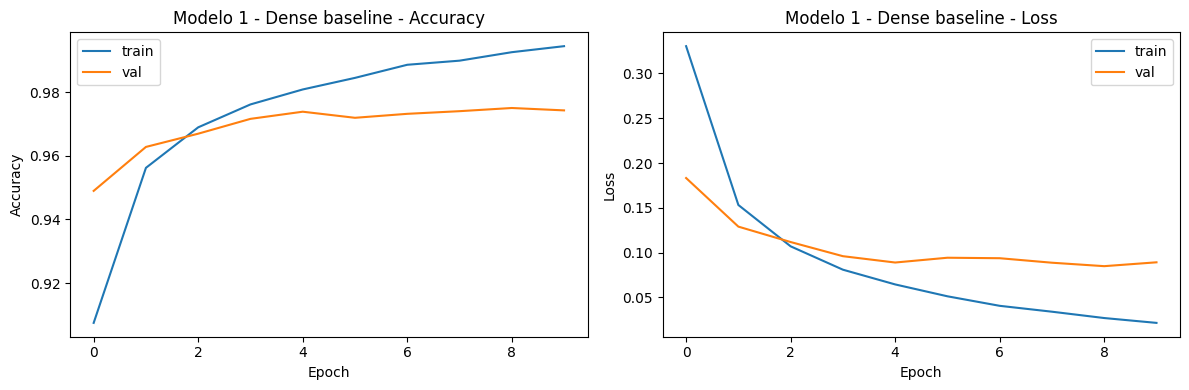

In [11]:
plot_history(history_1, "Modelo 1 - Dense baseline")

## Análisis solicitado

Responde:

1. ¿Qué accuracy obtiene el modelo?
2. ¿Hay diferencia entre accuracy de entrenamiento y validación?
3. ¿Este modelo aprovecha la estructura espacial de la imagen?
4. ¿Qué limitación tiene usar solo `Flatten + Dense`?

# Modelo 2 — Primera CNN sencilla

## Enunciado

Ahora construiremos una CNN mínima con una capa convolucional y una capa de pooling.

In [ ]:
model_2 = Sequential([
    Conv2D(32, (3, 3), activation="relu", input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(64, activation="relu"),
    Dense(10, activation="softmax")
])

model_2.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model_2.summary()

In [ ]:
history_2 = model_2.fit(
    X_train_mnist, y_train_mnist_cat,
    validation_split=0.2,
    epochs=10,
    batch_size=64
)

In [ ]:
test_loss_2, test_acc_2 = model_2.evaluate(X_test_mnist, y_test_mnist_cat, verbose=0)

results.append({
    "dataset": "MNIST",
    "modelo": "Modelo 2 - CNN sencilla",
    "tecnicas": "1 Conv2D + MaxPooling",
    "test_accuracy": test_acc_2,
    "test_loss": test_loss_2
})

print("Accuracy test:", test_acc_2)
print("Loss test:", test_loss_2)

In [ ]:
plot_history(history_2, "Modelo 2 - CNN sencilla")

## Preguntas

1. ¿Mejora respecto al modelo denso?
2. ¿Qué aprende la capa `Conv2D`?
3. ¿Qué efecto tiene `MaxPooling2D`?
4. ¿Qué ocurre con el tamaño de la imagen después de la convolución y el pooling?
5. ¿Por qué una CNN suele funcionar mejor en imágenes que una red densa simple?

# Modelo 3 — CNN más profunda

## Enunciado

Añade más bloques convolucionales para que el modelo aprenda características más complejas.

In [ ]:
model_3 = Sequential([
    Conv2D(32, (3, 3), activation="relu", input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(128, activation="relu"),
    Dense(10, activation="softmax")
])

model_3.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model_3.summary()

In [ ]:
history_3 = model_3.fit(
    X_train_mnist, y_train_mnist_cat,
    validation_split=0.2,
    epochs=10,
    batch_size=64
)

In [ ]:
test_loss_3, test_acc_3 = model_3.evaluate(X_test_mnist, y_test_mnist_cat, verbose=0)

results.append({
    "dataset": "MNIST",
    "modelo": "Modelo 3 - CNN profunda",
    "tecnicas": "2 Conv2D + MaxPooling",
    "test_accuracy": test_acc_3,
    "test_loss": test_loss_3
})

print("Accuracy test:", test_acc_3)
print("Loss test:", test_loss_3)

In [ ]:
plot_history(history_3, "Modelo 3 - CNN profunda")

## Análisis

Compara el modelo 1, 2 y 3.

Preguntas:

1. ¿Mejora el rendimiento al añadir más convoluciones?
2. ¿El modelo aprende más rápido?
3. ¿Hay señales de sobreentrenamiento?
4. ¿Qué modelo elegirías hasta ahora y por qué?

# Modelo 4 — CNN con Dropout

## Enunciado

Ahora añade `Dropout` para reducir el sobreentrenamiento.

In [ ]:
model_4 = Sequential([
    Conv2D(32, (3, 3), activation="relu", input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.5),
    Dense(10, activation="softmax")
])

model_4.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model_4.summary()

In [ ]:
history_4 = model_4.fit(
    X_train_mnist, y_train_mnist_cat,
    validation_split=0.2,
    epochs=10,
    batch_size=64
)

In [ ]:
test_loss_4, test_acc_4 = model_4.evaluate(X_test_mnist, y_test_mnist_cat, verbose=0)

results.append({
    "dataset": "MNIST",
    "modelo": "Modelo 4 - CNN + Dropout",
    "tecnicas": "2 Conv2D + Dropout",
    "test_accuracy": test_acc_4,
    "test_loss": test_loss_4
})

print("Accuracy test:", test_acc_4)
print("Loss test:", test_loss_4)

In [ ]:
plot_history(history_4, "Modelo 4 - CNN + Dropout")

## Preguntas

1. ¿Qué hace `Dropout(0.5)`?
2. ¿El accuracy de entrenamiento baja?
3. ¿El accuracy de validación mejora?
4. ¿Qué es más importante: tener mayor accuracy en entrenamiento o mejor generalización?

# Modelo 5 — CNN con Batch Normalization

## Enunciado

Añade `BatchNormalization` después de las convoluciones.

In [ ]:
model_5 = Sequential([
    Conv2D(32, (3, 3), activation="relu", input_shape=(28, 28, 1)),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation="relu"),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.5),
    Dense(10, activation="softmax")
])

model_5.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model_5.summary()

In [ ]:
history_5 = model_5.fit(
    X_train_mnist, y_train_mnist_cat,
    validation_split=0.2,
    epochs=10,
    batch_size=64
)

In [ ]:
test_loss_5, test_acc_5 = model_5.evaluate(X_test_mnist, y_test_mnist_cat, verbose=0)

results.append({
    "dataset": "MNIST",
    "modelo": "Modelo 5 - CNN + BN + Dropout",
    "tecnicas": "Conv2D + BatchNorm + Dropout",
    "test_accuracy": test_acc_5,
    "test_loss": test_loss_5
})

print("Accuracy test:", test_acc_5)
print("Loss test:", test_loss_5)

In [ ]:
plot_history(history_5, "Modelo 5 - CNN + BN + Dropout")

## Preguntas

1. ¿Qué efecto tiene `BatchNormalization`?
2. ¿El entrenamiento parece más estable?
3. ¿Mejora el resultado final?
4. ¿Batch Normalization sustituye a Dropout o pueden combinarse?

# Comparativa MNIST

In [ ]:
import pandas as pd

df_results = pd.DataFrame(results)
df_results[df_results["dataset"] == "MNIST"]

# Parte B — Dataset más difícil: CIFAR-10

CIFAR-10 contiene imágenes RGB de 32 × 32 píxeles.

Clases:

- airplane
- automobile
- bird
- cat
- deer
- dog
- frog
- horse
- ship
- truck

# 6. Carga de CIFAR-10

In [ ]:
(X_train_cifar, y_train_cifar), (X_test_cifar, y_test_cifar) = cifar10.load_data()

class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

print("X_train_cifar:", X_train_cifar.shape)
print("y_train_cifar:", y_train_cifar.shape)
print("X_test_cifar:", X_test_cifar.shape)
print("y_test_cifar:", y_test_cifar.shape)

# 7. Visualización de CIFAR-10

In [ ]:
plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train_cifar[i])
    plt.title(class_names[int(y_train_cifar[i])])
    plt.axis("off")

plt.tight_layout()
plt.show()

# 8. Preprocesado de CIFAR-10

In [ ]:
X_train_cifar = X_train_cifar.astype("float32") / 255.0
X_test_cifar = X_test_cifar.astype("float32") / 255.0

y_train_cifar_cat = to_categorical(y_train_cifar, 10)
y_test_cifar_cat = to_categorical(y_test_cifar, 10)

print("X_train_cifar:", X_train_cifar.shape)
print("X_test_cifar:", X_test_cifar.shape)
print("y_train_cifar_cat:", y_train_cifar_cat.shape)
print("y_test_cifar_cat:", y_test_cifar_cat.shape)

# Modelo 6 — CNN básica para CIFAR-10

## Enunciado

Construye una CNN sencilla para CIFAR-10.

In [ ]:
model_6 = Sequential([
    Conv2D(32, (3, 3), activation="relu", input_shape=(32, 32, 3)),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(128, activation="relu"),
    Dense(10, activation="softmax")
])

model_6.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model_6.summary()

In [ ]:
history_6 = model_6.fit(
    X_train_cifar, y_train_cifar_cat,
    validation_split=0.2,
    epochs=20,
    batch_size=64
)

In [ ]:
test_loss_6, test_acc_6 = model_6.evaluate(X_test_cifar, y_test_cifar_cat, verbose=0)

results.append({
    "dataset": "CIFAR-10",
    "modelo": "Modelo 6 - CNN básica",
    "tecnicas": "2 Conv2D + MaxPooling",
    "test_accuracy": test_acc_6,
    "test_loss": test_loss_6
})

print("Accuracy test:", test_acc_6)
print("Loss test:", test_loss_6)

In [ ]:
plot_history(history_6, "Modelo 6 - CNN básica CIFAR-10")

## Preguntas

1. ¿Obtiene peor resultado que en MNIST?
2. ¿Por qué CIFAR-10 es más difícil?
3. ¿Influye que las imágenes sean RGB?
4. ¿Qué clases parecen más difíciles de distinguir?

# Modelo 7 — CNN mejorada para CIFAR-10

## Enunciado

Construye una CNN más profunda con Dropout y Batch Normalization.

In [ ]:
model_7 = Sequential([
    Conv2D(32, (3, 3), activation="relu", padding="same", input_shape=(32, 32, 3)),
    BatchNormalization(),
    Conv2D(32, (3, 3), activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Conv2D(64, (3, 3), activation="relu", padding="same"),
    BatchNormalization(),
    Conv2D(64, (3, 3), activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Conv2D(128, (3, 3), activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Flatten(),
    Dense(256, activation="relu"),
    BatchNormalization(),
    Dropout(0.5),
    Dense(10, activation="softmax")
])

model_7.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model_7.summary()

In [ ]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [ ]:
history_7 = model_7.fit(
    X_train_cifar, y_train_cifar_cat,
    validation_split=0.2,
    epochs=50,
    batch_size=64,
    callbacks=[early_stop]
)

In [ ]:
test_loss_7, test_acc_7 = model_7.evaluate(X_test_cifar, y_test_cifar_cat, verbose=0)

results.append({
    "dataset": "CIFAR-10",
    "modelo": "Modelo 7 - CNN mejorada",
    "tecnicas": "CNN profunda + BN + Dropout + EarlyStopping",
    "test_accuracy": test_acc_7,
    "test_loss": test_loss_7
})

print("Accuracy test:", test_acc_7)
print("Loss test:", test_loss_7)

In [ ]:
plot_history(history_7, "Modelo 7 - CNN mejorada CIFAR-10")

## Preguntas

1. ¿Mejora respecto al modelo anterior?
2. ¿Qué aporta `padding="same"`?
3. ¿Por qué se usan más filtros en capas profundas?
4. ¿Qué función cumple `EarlyStopping`?
5. ¿Se observa sobreentrenamiento?
6. ¿Dónde se nota más el efecto del Dropout?

# Modelo 8 — Data Augmentation

## Enunciado

Ahora añade aumento de datos para mejorar la generalización.

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

datagen.fit(X_train_cifar)

In [ ]:
model_8 = Sequential([
    Conv2D(32, (3, 3), activation="relu", padding="same", input_shape=(32, 32, 3)),
    BatchNormalization(),
    Conv2D(32, (3, 3), activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Conv2D(64, (3, 3), activation="relu", padding="same"),
    BatchNormalization(),
    Conv2D(64, (3, 3), activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Conv2D(128, (3, 3), activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Flatten(),
    Dense(256, activation="relu"),
    BatchNormalization(),
    Dropout(0.5),
    Dense(10, activation="softmax")
])

model_8.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model_8.summary()

In [ ]:
early_stop_aug = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [ ]:
history_8 = model_8.fit(
    datagen.flow(X_train_cifar, y_train_cifar_cat, batch_size=64),
    validation_data=(X_test_cifar, y_test_cifar_cat),
    epochs=50,
    callbacks=[early_stop_aug]
)

In [ ]:
test_loss_8, test_acc_8 = model_8.evaluate(X_test_cifar, y_test_cifar_cat, verbose=0)

results.append({
    "dataset": "CIFAR-10",
    "modelo": "Modelo 8 - CNN + Data Augmentation",
    "tecnicas": "CNN profunda + BN + Dropout + Augmentation",
    "test_accuracy": test_acc_8,
    "test_loss": test_loss_8
})

print("Accuracy test:", test_acc_8)
print("Loss test:", test_loss_8)

In [ ]:
plot_history(history_8, "Modelo 8 - CNN con Data Augmentation")

## Preguntas

1. ¿Qué transformaciones se están aplicando a las imágenes?
2. ¿Por qué data augmentation ayuda a generalizar?
3. ¿Tiene sentido aplicar `horizontal_flip=True` en todas las clases?
4. ¿Qué ocurriría si aplicásemos rotaciones demasiado grandes?
5. ¿El modelo tarda más en entrenar?
6. ¿Mejora el resultado en test?

# 9. Matriz de confusión

Puedes elegir el modelo que quieras analizar. Por defecto, usaremos `model_7`.

Si has entrenado `model_8` y quieres analizarlo, cambia `model_to_analyze = model_7` por `model_to_analyze = model_8`.

In [ ]:
model_to_analyze = model_7

y_pred_probs = model_to_analyze.predict(X_test_cifar)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test_cifar.flatten()

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(ax=ax, xticks_rotation=45)
plt.title("Matriz de confusión - CIFAR-10")
plt.show()

## Preguntas sobre errores

1. ¿Qué clases se confunden más?
2. ¿Tiene sentido visualmente esa confusión?
3. ¿Se confunden más animales con animales o vehículos con vehículos?
4. ¿Qué harías para mejorar esas clases?
5. ¿Crees que el modelo está aprendiendo forma, color, textura o contexto?

# 10. Tabla final de resultados

In [ ]:
df_results = pd.DataFrame(results)
df_results

# 11. Entregable del alumno

El alumno deberá entregar este notebook completado con:

## Apartado 1 — MNIST

- Carga y visualización del dataset.
- Modelo denso simple.
- Primera CNN.
- CNN más profunda.
- CNN con Dropout.
- CNN con Batch Normalization.
- Tabla comparativa de resultados.
- Conclusiones.

## Apartado 2 — CIFAR-10

- Carga y visualización del dataset.
- CNN básica.
- CNN mejorada.
- CNN con data augmentation.
- Matriz de confusión.
- Análisis de clases más difíciles.
- Conclusiones finales.

# 12. Solución orientativa

## Conclusiones esperadas para MNIST

Una red densa simple puede funcionar razonablemente bien porque MNIST es un dataset sencillo. Sin embargo, no aprovecha explícitamente la estructura espacial de la imagen.

Al introducir convoluciones, el modelo suele mejorar porque aprende patrones locales: bordes, curvas, trazos y combinaciones de trazos.

El pooling reduce el tamaño de los mapas de características y hace el modelo más robusto ante pequeños desplazamientos.

Una CNN más profunda suele mejorar los resultados, aunque en MNIST no siempre se aprecia una diferencia enorme porque el problema ya es bastante fácil.

Dropout puede reducir el sobreentrenamiento, aunque en modelos pequeños puede bajar ligeramente el accuracy de entrenamiento.

Batch Normalization puede hacer el entrenamiento más estable.

---

## Conclusiones esperadas para CIFAR-10

CIFAR-10 es bastante más difícil que MNIST porque:

- Las imágenes son en color.
- Hay fondos variados.
- Los objetos son pequeños.
- Hay más variabilidad intra-clase.
- Algunas clases son visualmente parecidas.

Una CNN básica suele quedarse corta.

Al añadir más bloques convolucionales, Batch Normalization, Dropout y data augmentation, el modelo suele generalizar mejor.

Es normal que clases como `cat`, `dog`, `deer` y `horse` se confundan entre sí.

También pueden confundirse `automobile` y `truck`, o `airplane` y `ship` en algunas imágenes.

# 13. Preguntas finales de reflexión

1. ¿Qué diferencia principal hay entre una red densa y una CNN?
2. ¿Por qué las primeras capas convolucionales suelen aprender bordes o texturas simples?
3. ¿Por qué las capas profundas aprenden patrones más abstractos?
4. ¿Qué problema intenta solucionar Dropout?
5. ¿Qué problema intenta solucionar Batch Normalization?
6. ¿Qué diferencia hay entre mejorar el accuracy de entrenamiento y mejorar el accuracy de test?
7. ¿Por qué un modelo más grande no siempre es mejor?
8. ¿Qué harías si tu modelo sobreentrena?
9. ¿Qué harías si tu modelo no aprende suficiente?
10. ¿Cuándo tendría sentido usar transfer learning?

# 14. Extensión opcional

Prueba alguna de estas modificaciones:

- Cambiar el número de filtros: 16, 32, 64, 128.
- Cambiar el tamaño del kernel: `(3,3)` frente a `(5,5)`.
- Cambiar el valor de Dropout: `0.25`, `0.5`, `0.7`.
- Cambiar el optimizador: `adam`, `sgd`, `rmsprop`.
- Añadir más épocas.
- Usar `GlobalAveragePooling2D` en lugar de `Flatten`.
- Comparar el número de parámetros de cada modelo.
- Probar transfer learning con `MobileNetV2`.

# 15. Rúbrica sugerida

| Criterio | Peso |
|---|---:|
| Carga, visualización y preprocesado correcto | 15% |
| Construcción progresiva de modelos | 25% |
| Evaluación con métricas y gráficas | 20% |
| Comparación entre MNIST y CIFAR-10 | 15% |
| Análisis crítico de resultados | 20% |
| Limpieza y claridad del notebook | 5% |